# ACM — Banking Dataset (Marketing Targets)
**Lead University · Minería de Datos · Tarea 4**

Análisis de Correspondencias Múltiples sobre datos de campañas de marketing bancario.
Objetivo: explorar asociaciones entre el perfil del cliente (trabajo, educación, estado civil) y el resultado de la campaña para identificar segmentos de interés.

In [14]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import ACMAnalyzer
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

print('Librerías cargadas.')

Librerías cargadas.


---
## Parte 1 — Preparación de datos

### 1. Carga y exploración

In [15]:
df_raw = pd.read_csv('datos/Banking_Dataset.csv', sep=';')
print(f'Registros: {df_raw.shape[0]:,} | Variables: {df_raw.shape[1]}')
print()
print(df_raw.dtypes)
print()
df_raw.head()

Registros: 45,211 | Variables: 17

age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [16]:
print('Valores faltantes:')
print(df_raw.isnull().sum())
print()
print('Valores únicos por variable categórica:')
for c in df_raw.select_dtypes(include='object').columns:
    print(f'  {c}: {df_raw[c].nunique()} -> {df_raw[c].unique().tolist()}')

Valores faltantes:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Valores únicos por variable categórica:
  job: 12 -> ['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', 'retired', 'admin.', 'services', 'self-employed', 'unemployed', 'housemaid', 'student']
  marital: 3 -> ['married', 'single', 'divorced']
  education: 4 -> ['tertiary', 'secondary', 'unknown', 'primary']
  default: 2 -> ['no', 'yes']
  housing: 2 -> ['yes', 'no']
  loan: 2 -> ['no', 'yes']
  contact: 3 -> ['unknown', 'cellular', 'telephone']
  month: 12 -> ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr', 'sep']
  poutcome: 4 -> ['unknown', 'failure', 'other', 'success']
  y: 2 -> ['no', 'yes']


### 2. Limpieza

- No hay valores faltantes (NaN). La categoría `unknown` se conserva como modalidad válida (refleja información que no fue recolectada durante la campaña).
- Se eliminan 5 variables numéricas de la mecánica de contacto que no describen el perfil del cliente:
  - `day`: día del mes del contacto — no tiene significado categórico (1-31 sin patrón).
  - `duration`: duración de la última llamada — es un *target leak* (si la llamada fue larga, el cliente ya estaba interesado; no se conoce antes de contactar).
  - `campaign`: número de contactos en esta campaña — describe la insistencia del banco, no al cliente.
  - `pdays`: días desde el último contacto previo — valor -1 en el 76% de registros (nunca contactado), dominaría artificialmente un eje.
  - `previous`: número de contactos en campañas anteriores — mismo problema que `campaign`.
- Las variables numéricas retenidas (`age`, `balance`) serán discretizadas automáticamente por `ACMAnalyzer` en cuartiles.

### 3-4. Selección de variables y discretización

Se conservan las variables categóricas del perfil del cliente (`job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `poutcome`, `y`) y las numéricas relevantes (`age`, `balance`) que se discretizan automáticamente en cuartiles.

**Nota sobre el tamaño muestral:** Se realizó una prueba comparativa entre una muestra de 15K registros y el dataset completo (45K). Los resultados fueron prácticamente idénticos, no obstante, se decidió usar todos los registros para maximizar la representatividad de modalidades poco frecuentes (ej. `default: yes`, `job: student`).

In [17]:
df = df_raw.copy()
print(f'Registros: {len(df):,}')
print(f'Variables: {df.shape[1]}')

Registros: 45,211
Variables: 17


---
## Parte 2 — Aplicación del ACM

### 6. ¿Qué es el ACM?

El **Análisis de Correspondencias Múltiples (ACM)** es una extensión del ACS para analizar simultáneamente las asociaciones entre más de dos variables categóricas. Opera sobre la tabla disyuntiva completa (codificación 0/1 de todas las modalidades) y aplica una descomposición en valores singulares (SVD) ponderada por chi-cuadrado.

**Objetivo:** Reducir la dimensionalidad de datos categóricos preservando las asociaciones entre modalidades. Permite visualizar qué categorías tienden a aparecer juntas y qué individuos comparten perfiles similares.

**¿Por qué es apropiado para este dataset?** Las variables principales del marketing bancario son categóricas (tipo de trabajo, estado civil, nivel educativo, resultado de campaña). El ACM permite detectar qué perfiles de cliente se asocian con la suscripción al producto (`y=yes`), sin imponer un modelo supervisado.

### 5. Ajuste del ACM

In [18]:
drop = ['day', 'duration', 'campaign', 'pdays', 'previous']
fx = ACMAnalyzer(df, drop_cols=drop)
fx.fit(n_plot=2)

display(fx.summary())

,metodo,dim1,dim2,acum_1_2
0,PCA,7.70,5.74,13.44
1,ACM,5.64,4.75,10.39


### 7. Tabla de inercia explicada por componente

In [19]:
fx.plot_inertia(n=10)

PCA


,autovalor,% total,% acum
0,3.697,7.702,7.702
1,2.755,5.739,13.442
2,2.416,5.033,18.474
3,2.378,4.954,23.428
4,2.174,4.529,27.957
5,1.988,4.141,32.098
6,1.817,3.786,35.884
7,1.559,3.247,39.131
8,1.544,3.217,42.349
9,1.390,2.897,45.245


ACM


,autovalor,% total,% acum
0,0.197,5.642,5.642
1,0.166,4.751,10.394
2,0.136,3.896,14.289
3,0.132,3.779,18.068
4,0.124,3.541,21.609
5,0.108,3.073,24.682
6,0.104,2.972,27.654
7,0.100,2.850,30.504
8,0.096,2.752,33.257
9,0.094,2.689,35.946


### 8. Scree plot

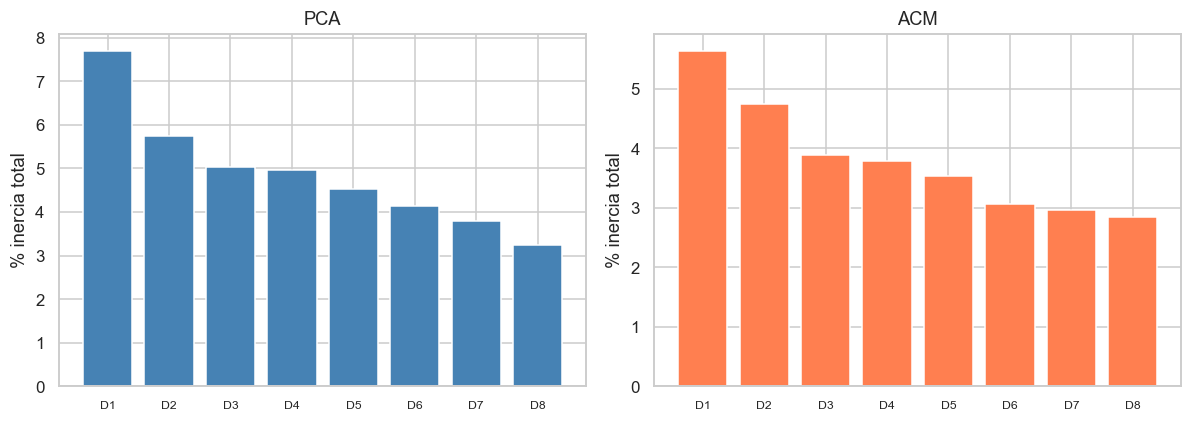

In [20]:
fx.plot_scree()

### 9. Elección de componentes

La inercia se distribuye de forma muy uniforme: D1=5.6%, D2=4.8%, D3=3.9%, D4=3.8%... La caída entre D1 y D2 es de ~0.9 puntos, y luego entre D2 y D3 hay otro salto similar. No hay un codo marcado como en vuelos.

Se seleccionan las **primeras 2 dimensiones** como plano principal:
1. D1 y D2 son las únicas que superan el promedio teórico (~2.9% = 100/34 dimensiones posibles) por más de 2 puntos.
2. Acumulan 10.4% de inercia — bajo en términos absolutos, pero con 43 modalidades es esperable.
3. El biplot muestra que este plano ya captura contrastes interpretables (edad/tipo de contacto vs resultado de campaña).

---
## Parte 3 — Interpretación del espacio factorial

### 10-11. Biplot del ACM

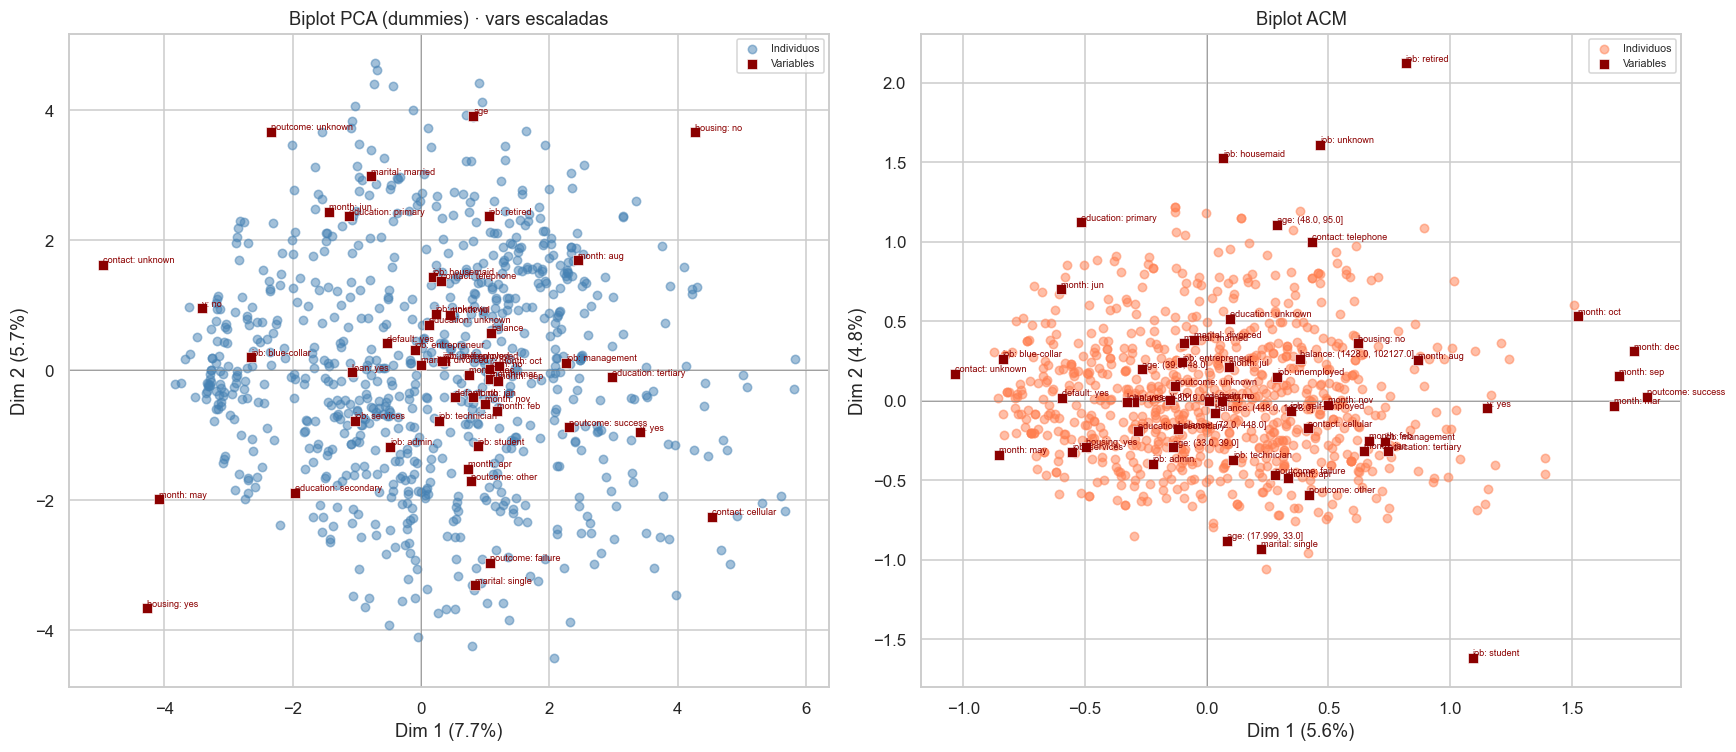

In [21]:
fx.plot_biplots()

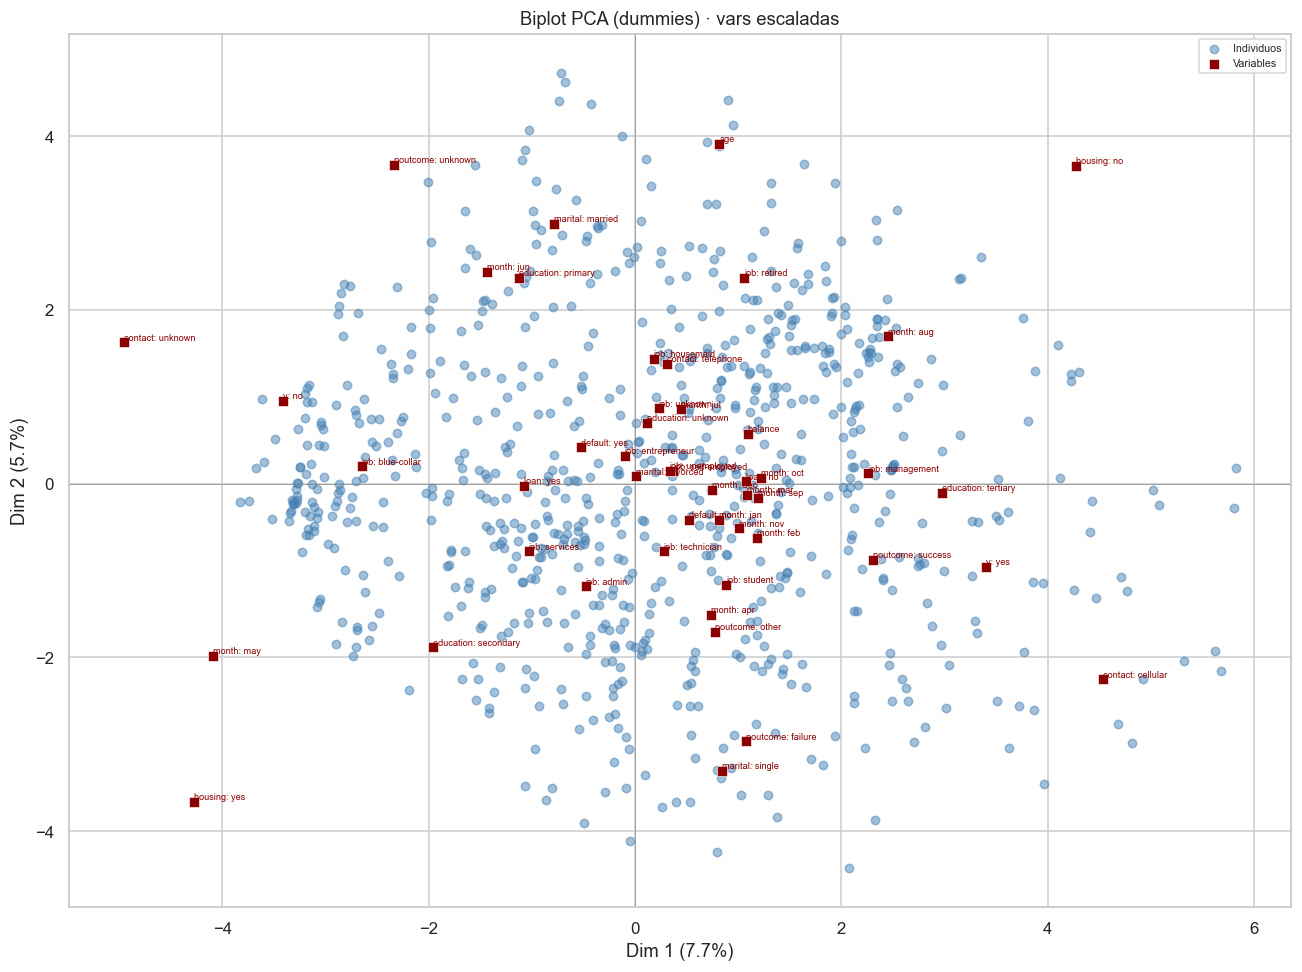

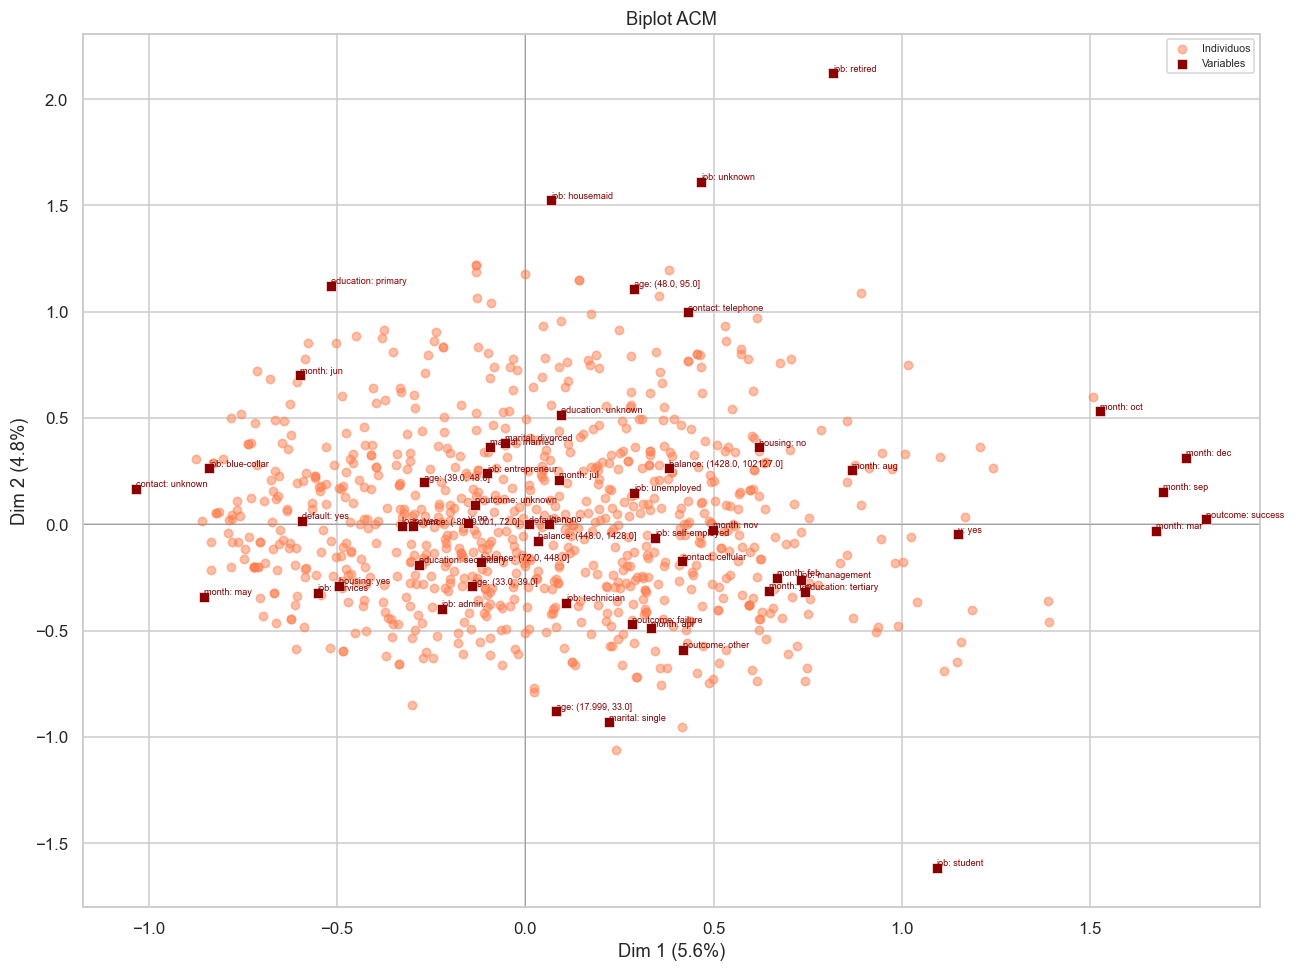

In [22]:
fx.plot_biplots(individual=True)

**Interpretación del biplot ACM:**

**Dim 1 (5.6%) — Eje de contactabilidad y resultado de campaña:**
- A la derecha: `poutcome: success`, `y: yes`, `month: oct/sep/dec/mar`, `job: student`, `housing: no`, `balance: (1428, 102127]`, `education: tertiary`. Perfil de clientes que suscribieron al producto: contactados en meses fuera del pico, con campañas previas exitosas.
- A la izquierda: `contact: unknown`, `month: may/jun`, `job: blue-collar`, `default: yes`, `housing: yes`, `education: primary`. Perfil de clientes no alcanzados o contactados en la campaña masiva de mayo (sin historial previo).

**Dim 2 (4.8%) — Eje de edad y etapa de vida:**
- Arriba: `job: retired`, `age: (48, 95]`, `job: housemaid`, `job: unknown`, `education: primary`, `contact: telephone`. Perfil de personas mayores, contactadas por teléfono fijo.
- Abajo: `marital: single`, `age: (18, 33]`, `job: student`, `poutcome: failure/other`. Perfil joven, soltero, con campañas previas fallidas.

**Asociaciones principales:**
- `y: yes` ↔ `poutcome: success` están próximos a la derecha — la mejor predicción de suscripción es haber tenido una campaña previa exitosa.
- `contact: unknown` ↔ `poutcome: unknown` ↔ `month: may` forman un cluster a la izquierda — representan la gran masa de clientes contactados por primera vez en la campaña masiva, sin historial.
- `job: retired` + `age: alto` se separan hacia arriba — los jubilados forman un perfil diferenciado que no se mezcla con el resto.
- Las modalidades mayoritarias (`default: no`, `loan: no`, `marital: married`) están cerca del origen, como se espera del perfil promedio.

### Comparación ACM vs PCA

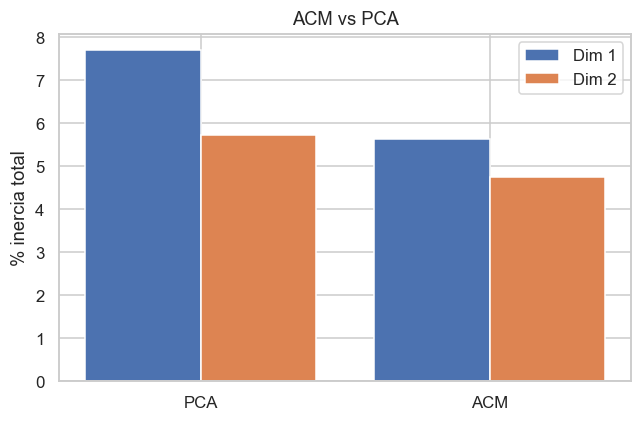

In [23]:
fx.plot_comparison()

### 12. Contribuciones y calidad de representación (cos²)

In [24]:
fx.show_contrib_cos2(n=12)

Contribuciones de variables (dims 1-2): PCA vs ACM


,PCA_variable,PCA_contrib,ACM_variable,ACM_contrib
rank,,,,
1,housing: yes,0.1943,"age: (48.0, 95.0]",0.1608
2,housing: no,0.1943,contact: unknown,0.1337
3,contact: unknown,0.1504,marital: single,0.1288
4,contact: cellular,0.1467,job: retired,0.1270
5,poutcome: unknown,0.1260,"age: (17.999, 33.0]",0.1129
6,month: may,0.1180,education: primary,0.1127
7,age,0.1138,month: may,0.1113
8,marital: single,0.0825,housing: no,0.1012
9,poutcome: failure,0.0695,education: tertiary,0.0834


Resumen cos² de individuos en el plano 1-2


,metodo,cos2_media,cos2_mediana,cos2_min,pct_cos2>=0.5
0,PCA,0.1629,0.1287,0.0,2.0836
1,ACM,0.1212,0.0907,0.0,0.0000


Top 12 individuos por cos²: PCA vs ACM


,PCA_individuo,PCA_cos2,ACM_individuo,ACM_cos2
rank,,,,
1,4686,0.6119,39805,0.4729
2,832,0.6119,40766,0.4689
3,143,0.6119,40619,0.4689
4,3584,0.6118,41290,0.4689
5,1319,0.6118,44483,0.4689
6,1465,0.6118,41183,0.4689
7,1867,0.6118,19372,0.4689
8,5642,0.6118,10427,0.4647
9,2351,0.6118,10816,0.4647


### 13. Perfiles similares en el espacio reducido

El ACM revela tres perfiles distinguibles en el plano:

1. **Perfil "campaña exitosa" (derecha):** Clientes con `poutcome: success`, `y: yes`, contactados en meses de bajo volumen (oct, sep, mar), con balance alto, sin hipoteca (`housing: no`), educación terciaria. Son los clientes ya fidelizados que responden bien a recontacto.

2. **Perfil "campaña masiva sin historial" (izquierda):** Clientes con `contact: unknown`, `poutcome: unknown`, contactados en mayo/junio. Son la mayoría — primer contacto, sin historial previo, perfil genérico (blue-collar, housing: yes, educación primaria/secundaria).

3. **Perfil "jubilados" (arriba):** `job: retired`, edad >48, contactados por teléfono fijo. Se separan verticalmente de los demás perfiles — etapa de vida diferente con necesidades financieras distintas.

El cos² es bajo (media = 0.12, máximo ~0.47), indicando que dos dimensiones no capturan toda la complejidad del perfil del cliente. Esto es esperable: con 12 variables categóricas y 43 modalidades, la estructura se reparte entre muchas dimensiones. No obstante, los contrastes principales (historial de campaña, edad, tipo de contacto) sí son visibles en el plano.